# Huấn luyện mô hình — Random Forest (DKA-AKI)

## Mục tiêu
Theo mục *12. Bước tiếp theo* của notebook tiền xử lý:
1. Đọc `train_processed.csv`, tách `X`, `y`, chia train/validation **theo phân tầng (stratify)**.
2. Huấn luyện **Random Forest** (mô hình cơ bản đầu tiên).
3. Đánh giá trên validation bằng các độ đo của bài báo (AUC, accuracy, sensitivity, specificity, F1).
4. Áp dụng **cùng** `flatten` + `preprocessor.joblib` (chỉ `transform`) cho `test.json`.
5. Dự đoán tập test và ghi kết quả ra thư mục `output/`.

> Yêu cầu: đã chạy `preprocessing.ipynb` để sinh ra `data/train_processed.csv` và `data/preprocessor.joblib`.

## 1. Thư viện sử dụng

In [1]:
import os
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, accuracy_score, f1_score,
                             confusion_matrix, classification_report, roc_curve)

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
%matplotlib inline

## 2. Đọc dữ liệu đã xử lý

`train_processed.csv` do bước tiền xử lý sinh ra: các đặc trưng đã làm sạch/chuẩn hoá + cột nhãn `akdPositive`.

In [2]:
DATA_DIR = os.path.join('..', 'data')
OUTPUT_DIR = os.path.join('..', 'output')
os.makedirs(OUTPUT_DIR, exist_ok=True)

TARGET = 'akdPositive'
data = pd.read_csv(os.path.join(DATA_DIR, 'train_processed.csv'))
X = data.drop(columns=[TARGET])
y = data[TARGET]
print('Kích thước X:', X.shape, '| số đặc trưng:', X.shape[1])
print('Phân bố nhãn:', dict(y.value_counts()))
print('Tỉ lệ dương tính: {:.1%}'.format(y.mean()))

Kích thước X: (970, 77) | số đặc trưng: 77
Phân bố nhãn: {0: 593, 1: 377}
Tỉ lệ dương tính: 38.9%


**Nhận xét:** **970 bệnh nhân × 77 đặc trưng**, tỉ lệ dương tính ≈ **38.9%** (mất cân bằng nhẹ). Vì vậy ta sẽ (1) chia dữ liệu **stratify** và (2) dùng `class_weight='balanced'` cho Random Forest.

## 3. Chia train / validation (phân tầng)

Vì tập `test.json` **không có nhãn**, ta tách 20% dữ liệu train làm **validation** để đánh giá mô hình. `stratify=y` giữ nguyên tỉ lệ 39% ở cả hai phần.

In [3]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
print('Train:', X_tr.shape, '| Validation:', X_val.shape)
print('Tỉ lệ dương tính — train: {:.1%}, val: {:.1%}'.format(y_tr.mean(), y_val.mean()))

Train: (776, 77) | Validation: (194, 77)
Tỉ lệ dương tính — train: 38.9%, val: 38.7%


**Nhận xét:** ~776 mẫu train / ~194 mẫu validation, tỉ lệ dương tính giữ nguyên ở cả hai (nhờ `stratify`).

## 4. Huấn luyện Random Forest

Random Forest là tập hợp nhiều cây quyết định (giảm overfitting so với một cây). Tham số chính:
- `n_estimators=300`: số cây.
- `class_weight='balanced'`: bù cho việc nhãn mất cân bằng.
- `random_state` cố định để tái lập kết quả.

In [4]:
rf = RandomForestClassifier(
    n_estimators=300, max_depth=None, min_samples_leaf=2,
    class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE)
rf.fit(X_tr, y_tr)
print('Đã huấn luyện xong Random Forest với', rf.n_estimators, 'cây.')

Đã huấn luyện xong Random Forest với 300 cây.


**Nhận xét:** mô hình đã học xong trên tập train. Tiếp theo đánh giá khả năng tổng quát hoá trên validation.

## 5. Đánh giá trên tập validation

Dùng đúng các độ đo của bài báo:
- **AUC**: khả năng phân biệt 2 lớp (càng gần 1 càng tốt).
- **Sensitivity** (độ nhạy/recall lớp dương): tỉ lệ bắt đúng ca AKI — rất quan trọng trên lâm sàng.
- **Specificity** (độ đặc hiệu): tỉ lệ nhận đúng ca không AKI.
- **Accuracy**, **F1**.

In [5]:
proba_val = rf.predict_proba(X_val)[:, 1]
pred_val = (proba_val >= 0.5).astype(int)

auc = roc_auc_score(y_val, proba_val)
acc = accuracy_score(y_val, pred_val)
f1 = f1_score(y_val, pred_val)
tn, fp, fn, tp = confusion_matrix(y_val, pred_val).ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print('AUC        : {:.3f}'.format(auc))
print('Accuracy   : {:.3f}'.format(acc))
print('Sensitivity: {:.3f}'.format(sensitivity))
print('Specificity: {:.3f}'.format(specificity))
print('F1         : {:.3f}'.format(f1))
print('\nConfusion matrix [[TN, FP], [FN, TP]]:')
print(confusion_matrix(y_val, pred_val))
print('\n', classification_report(y_val, pred_val, target_names=['no-AKI', 'AKI']))

AUC        : 0.806
Accuracy   : 0.753
Sensitivity: 0.667
Specificity: 0.807
F1         : 0.676

Confusion matrix [[TN, FP], [FN, TP]]:
[[96 23]
 [25 50]]

               precision    recall  f1-score   support

      no-AKI       0.79      0.81      0.80       119
         AKI       0.68      0.67      0.68        75

    accuracy                           0.75       194
   macro avg       0.74      0.74      0.74       194
weighted avg       0.75      0.75      0.75       194



**Cách đọc kết quả:** bài báo đạt **AUC ≈ 0.80** trên tập validation với XGBoost — đây là mốc tham chiếu. Random Forest thường cho AUC tương đương. Nếu **sensitivity thấp** (bỏ sót ca AKI), có thể **hạ ngưỡng** dự đoán xuống dưới 0.5 hoặc tăng `class_weight`. Ma trận nhầm lẫn cho biết mô hình sai ở đâu (FP vs FN).

### 5.1 So sánh Train vs Validation (kiểm tra overfitting)

Cùng các độ đo trên nhưng tính cho **cả tập train lẫn validation**. Chênh lệch lớn giữa hai cột ⇒ mô hình **overfit** (học thuộc dữ liệu train, kém tổng quát hoá).

In [6]:
def compute_metrics(model, X, y):
    proba = model.predict_proba(X)[:, 1]
    pred = (proba >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred).ravel()
    return {
        'AUC': roc_auc_score(y, proba),
        'Accuracy': accuracy_score(y, pred),
        'Sensitivity': tp / (tp + fn),
        'Specificity': tn / (tn + fp),
        'F1': f1_score(y, pred),
    }

compare = pd.DataFrame({
    'Train': compute_metrics(rf, X_tr, y_tr),
    'Validation': compute_metrics(rf, X_val, y_val),
}).round(3)
print('Hiệu năng Random Forest — Train vs Validation:')
print(compare)

Hiệu năng Random Forest — Train vs Validation:
             Train  Validation
AUC          1.000       0.806
Accuracy     0.997       0.753
Sensitivity  1.000       0.667
Specificity  0.996       0.807
F1           0.997       0.676


**Nhận xét:** Random Forest thường đạt độ đo trên **train rất cao** (Accuracy/AUC gần 1.0) vì các cây học gần như thuộc lòng dữ liệu train — điều này **bình thường**. Quan trọng là **mức trên validation** và **khoảng cách train − validation**: chênh lệch càng lớn thì overfit càng nặng. Nếu overfit nhiều, có thể giảm độ phức tạp (tăng `min_samples_leaf`, giảm `max_depth`) hoặc tăng dữ liệu/đặc trưng.

### 5.2 Đường cong ROC

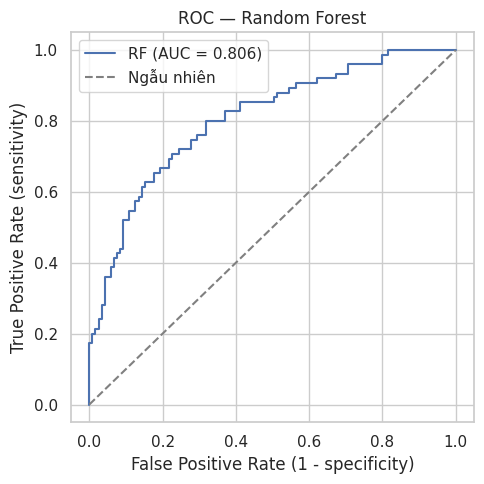

In [7]:
fpr, tpr, _ = roc_curve(y_val, proba_val)
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label='RF (AUC = {:.3f})'.format(auc))
plt.plot([0, 1], [0, 1], '--', color='gray', label='Ngẫu nhiên')
plt.xlabel('False Positive Rate (1 - specificity)')
plt.ylabel('True Positive Rate (sensitivity)')
plt.title('ROC — Random Forest'); plt.legend(); plt.tight_layout()
plt.show()

**Nhận xét:** đường ROC càng cong lên góc trái trên càng tốt; diện tích dưới đường = AUC ở trên.

## 6. Độ quan trọng của đặc trưng

Random Forest cho biết đặc trưng nào đóng góp nhiều nhất vào dự đoán. Ta đối chiếu với bài báo (top 5: **BUN, urine output, weight, age, PLT**; ở dữ liệu này không có urine output).

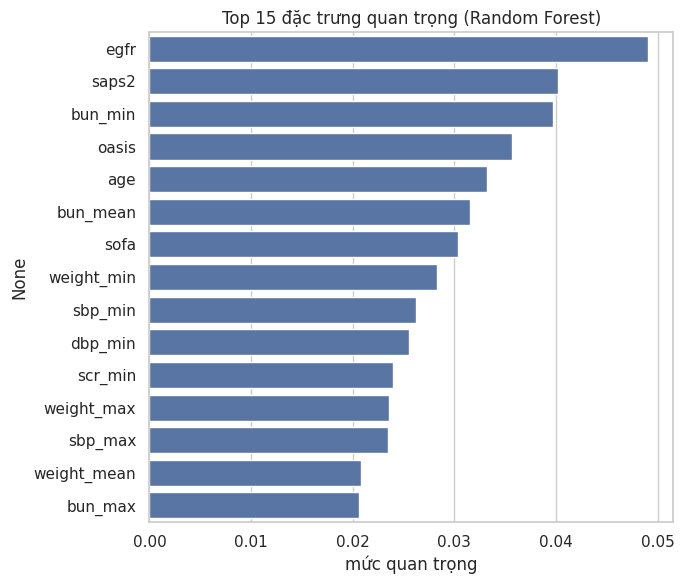

egfr           0.0491
saps2          0.0402
bun_min        0.0397
oasis          0.0356
age            0.0332
bun_mean       0.0316
sofa           0.0304
weight_min     0.0283
sbp_min        0.0262
dbp_min        0.0256
scr_min        0.0240
weight_max     0.0235
sbp_max        0.0234
weight_mean    0.0208
bun_max        0.0206
dtype: float64

In [8]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
top = importances.head(15)
plt.figure(figsize=(7, 6))
sns.barplot(x=top.values, y=top.index)
plt.title('Top 15 đặc trưng quan trọng (Random Forest)'); plt.xlabel('mức quan trọng')
plt.tight_layout(); plt.show()
top.round(4)

**Nhận xét:** kỳ vọng các đặc trưng liên quan đến **BUN, tuổi, cân nặng, độ nặng (SAPS2/OASIS/SOFA), eGFR** nằm ở nhóm đầu — trùng hướng với phân tích tương quan ở notebook tiền xử lý và với bài báo.

## 7. Tinh chỉnh siêu tham số (Hyperparameter Tuning)

Theo quy trình tinh chỉnh Random Forest (xem skill `random-forest-hyperparameter-tuning`):
1. **Baseline** — ghi lại cấu hình hiện tại làm mốc tham chiếu.
2. **Grid search toàn diện** — thử **mọi** tổ hợp của các siêu tham số quan trọng, đánh giá bằng **Stratified 5-fold CV** với độ đo **ROC-AUC** (phù hợp dữ liệu mất cân bằng, không phụ thuộc ngưỡng).
3. **So sánh** baseline vs cấu hình tốt nhất (kèm kiểm tra overfitting train − validation).
4. **Điều chỉnh ngưỡng** quyết định cho mục tiêu lâm sàng (ưu tiên sensitivity / F1).

> Mọi thí nghiệm được ghi vào log trong `output/`:
> - `rf_experiment_log.md` — nhật ký đọc cho người (mỗi thí nghiệm: đổi gì, kết quả ra sao).
> - `rf_experiment_log.csv` — bảng tổng hợp các thí nghiệm.
> - `rf_grid_search_all.csv` — **toàn bộ** tổ hợp grid đã thử cùng điểm CV (test all possibilities).

### 7.1 Thiết lập nhật ký & ghi lại baseline

Hàm `log_experiment(...)` ghi đồng thời vào file `.md` (đọc) và `.csv` (bảng).
Thí nghiệm đầu tiên ghi lại **chính cấu hình đang dùng** ở mục 4 để làm mốc so sánh.

In [9]:
import csv
import datetime
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score

LOG_MD   = os.path.join(OUTPUT_DIR, 'rf_experiment_log.md')
LOG_CSV  = os.path.join(OUTPUT_DIR, 'rf_experiment_log.csv')
GRID_CSV = os.path.join(OUTPUT_DIR, 'rf_grid_search_all.csv')

# CV dùng chung cho baseline và grid search -> so sánh công bằng
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

LOG_FIELDS = ['timestamp', 'experiment', 'changed_vs_baseline',
              'n_estimators', 'max_depth', 'min_samples_split', 'min_samples_leaf',
              'max_features', 'bootstrap', 'class_weight', 'threshold',
              'cv_auc_mean', 'cv_auc_std', 'val_AUC', 'val_Accuracy',
              'val_Sensitivity', 'val_Specificity', 'val_F1', 'notes']


def _init_logs():
    with open(LOG_MD, 'w', encoding='utf-8') as f:
        f.write('# Nhật ký tinh chỉnh Random Forest (DKA-AKI)\n\n')
        f.write('Dữ liệu: 970 × 77 | dương tính 38.9% | CV: Stratified 5-fold | '
                'độ đo chọn mô hình: **ROC-AUC** | `random_state=42`.\n\n')
        f.write('Sinh tự động bởi notebook `modeling_randomforest.ipynb` mục 7.\n\n---\n\n')
    with open(LOG_CSV, 'w', newline='', encoding='utf-8') as f:
        csv.DictWriter(f, fieldnames=LOG_FIELDS).writeheader()


def val_metrics_at(model, X, y, threshold=0.5):
    """Các độ đo trên một tập, ở một ngưỡng quyết định."""
    proba = model.predict_proba(X)[:, 1]
    pred = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred).ravel()
    return {'AUC': roc_auc_score(y, proba), 'Accuracy': accuracy_score(y, pred),
            'Sensitivity': tp / (tp + fn), 'Specificity': tn / (tn + fp),
            'F1': f1_score(y, pred)}


def log_experiment(name, params, cv_mean, cv_std, val_metrics,
                   changed='', threshold=0.5, notes=''):
    ts = datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    row = {'timestamp': ts, 'experiment': name, 'changed_vs_baseline': changed,
           'n_estimators': params.get('n_estimators'), 'max_depth': params.get('max_depth'),
           'min_samples_split': params.get('min_samples_split'),
           'min_samples_leaf': params.get('min_samples_leaf'),
           'max_features': params.get('max_features'), 'bootstrap': params.get('bootstrap'),
           'class_weight': params.get('class_weight'), 'threshold': round(threshold, 3),
           'cv_auc_mean': None if cv_mean is None else round(cv_mean, 4),
           'cv_auc_std': None if cv_std is None else round(cv_std, 4),
           'val_AUC': round(val_metrics['AUC'], 4), 'val_Accuracy': round(val_metrics['Accuracy'], 4),
           'val_Sensitivity': round(val_metrics['Sensitivity'], 4),
           'val_Specificity': round(val_metrics['Specificity'], 4),
           'val_F1': round(val_metrics['F1'], 4), 'notes': notes}
    with open(LOG_CSV, 'a', newline='', encoding='utf-8') as f:
        csv.DictWriter(f, fieldnames=LOG_FIELDS).writerow(row)
    with open(LOG_MD, 'a', encoding='utf-8') as f:
        f.write('## {}  \n_{}_\n'.format(name, ts))
        if changed:
            f.write('- **Thay đổi so với baseline:** {}\n'.format(changed))
        f.write('- **Tham số:** n_estimators={}, max_depth={}, min_samples_split={}, '
                'min_samples_leaf={}, max_features={}, bootstrap={}, class_weight={}\n'.format(
                    row['n_estimators'], row['max_depth'], row['min_samples_split'],
                    row['min_samples_leaf'], row['max_features'], row['bootstrap'],
                    row['class_weight']))
        if cv_mean is not None:
            f.write('- **CV ROC-AUC:** {:.4f} ± {:.4f}\n'.format(cv_mean, cv_std))
        f.write('- **Validation @ngưỡng {:.2f}:** AUC={AUC:.3f}, Accuracy={Accuracy:.3f}, '
                'Sensitivity={Sensitivity:.3f}, Specificity={Specificity:.3f}, '
                'F1={F1:.3f}\n'.format(threshold, **val_metrics))
        if notes:
            f.write('- **Ghi chú:** {}\n'.format(notes))
        f.write('\n')
    return row


_init_logs()

# --- Thí nghiệm 0: BASELINE (đúng cấu hình mục 4 của notebook) ---
baseline_params = {'n_estimators': 300, 'max_depth': None, 'min_samples_split': 2,
                   'min_samples_leaf': 2, 'max_features': 'sqrt', 'bootstrap': True,
                   'class_weight': 'balanced'}
base_cv = cross_val_score(rf, X_tr, y_tr, cv=CV, scoring='roc_auc', n_jobs=-1)
base_val = val_metrics_at(rf, X_val, y_val, 0.5)
log_experiment('Baseline (cấu hình hiện tại — mục 4)', baseline_params,
               base_cv.mean(), base_cv.std(), base_val,
               changed='(mốc tham chiếu)', threshold=0.5,
               notes='Cấu hình đang dùng trong notebook trước khi tinh chỉnh.')
print('Baseline CV ROC-AUC : {:.4f} ± {:.4f}'.format(base_cv.mean(), base_cv.std()))
print('Baseline validation :', {k: round(v, 3) for k, v in base_val.items()})

Baseline CV ROC-AUC : 0.8042 ± 0.0438
Baseline validation : {'AUC': 0.806, 'Accuracy': 0.753, 'Sensitivity': 0.667, 'Specificity': 0.807, 'F1': 0.676}


### 7.2 Grid search toàn diện (thử mọi tổ hợp)

Không gian tìm kiếm (xem `reference/parameters.md`):

| Tham số | Các giá trị thử |
|---|---|
| `n_estimators` | 200, 300, 500, 800 |
| `max_depth` | None, 5, 10, 20, 30 |
| `min_samples_split` | 2, 5, 10 |
| `min_samples_leaf` | 1, 2, 4 |
| `max_features` | 'sqrt', 'log2', 0.5 |
| `bootstrap` | True, False |

`class_weight='balanced'` được giữ cố định (xử lý mất cân bằng). `GridSearchCV` thử **tất cả** tổ hợp với 5-fold CV; **toàn bộ** kết quả được lưu ra `rf_grid_search_all.csv`.

In [10]:
param_grid = {
    'n_estimators':      [200, 300, 500, 800],
    'max_depth':         [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2', 0.5],
    'bootstrap':         [True, False],
}
n_combos = 1
for v in param_grid.values():
    n_combos *= len(v)
print('Tổng số tổ hợp:', n_combos, '| số lần huấn luyện (×5 fold):', n_combos * 5)

# n_jobs=-1 cho search (song song theo tổ hợp); estimator để n_jobs=1 tránh tranh nhân.
gs = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', n_jobs=1, random_state=RANDOM_STATE),
    param_grid, cv=CV, scoring='roc_auc', n_jobs=-1, refit=True, verbose=1)
gs.fit(X_tr, y_tr)

# Lưu TOÀN BỘ tổ hợp đã thử + điểm CV (test all possibilities)
res = pd.DataFrame(gs.cv_results_)
param_cols = ['param_' + k for k in param_grid]
res_out = (res[param_cols + ['mean_test_score', 'std_test_score', 'rank_test_score']]
           .sort_values('rank_test_score').reset_index(drop=True))
res_out.to_csv(GRID_CSV, index=False)
print('Đã lưu toàn bộ {} tổ hợp -> {}'.format(len(res_out), GRID_CSV))
print('\nBest CV ROC-AUC: {:.4f}'.format(gs.best_score_))
print('Best params    :', gs.best_params_)
res_out.head(10)

Tổng số tổ hợp: 1080 | số lần huấn luyện (×5 fold): 5400
Fitting 5 folds for each of 1080 candidates, totalling 5400 fits
Đã lưu toàn bộ 1080 tổ hợp -> ../output/rf_grid_search_all.csv

Best CV ROC-AUC: 0.8109
Best params    : {'bootstrap': True, 'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 500}


,param_n_estimators,param_max_depth,param_min_samples_split,param_min_samples_leaf,param_max_features,param_bootstrap,mean_test_score,std_test_score,rank_test_score
0,500,30,2,2,log2,True,0.810943,0.044525,1
1,500,20,2,2,log2,True,0.810943,0.044525,1
2,500,None,2,2,log2,True,0.810943,0.044525,1
3,800,20,2,2,log2,True,0.809055,0.044549,4
4,800,30,2,2,log2,True,0.808985,0.044565,5
5,800,None,2,2,log2,True,0.808985,0.044565,5
6,300,20,10,1,0.5,True,0.808898,0.043772,7
7,300,30,10,1,0.5,True,0.808898,0.043772,7
8,300,None,10,1,0.5,True,0.808898,0.043772,7
9,800,30,2,2,sqrt,True,0.808887,0.044864,10


### 7.3 So sánh cấu hình tốt nhất vs baseline

Đánh giá mô hình tốt nhất trên **validation** (cùng tập đã tách), kiểm tra khoảng cách train − validation và ghi vào nhật ký.

In [11]:
best_rf = gs.best_estimator_           # đã refit trên X_tr
best_params = dict(gs.best_params_)
best_full_params = {**best_params, 'class_weight': 'balanced'}

best_val = val_metrics_at(best_rf, X_val, y_val, 0.5)
best_tr = val_metrics_at(best_rf, X_tr, y_tr, 0.5)

# Diễn giải những gì đã đổi so với baseline
changes = []
for k in ['n_estimators', 'max_depth', 'min_samples_split', 'min_samples_leaf',
          'max_features', 'bootstrap']:
    if best_params.get(k) != baseline_params.get(k):
        changes.append('{}: {} → {}'.format(k, baseline_params.get(k), best_params.get(k)))
changed_str = '; '.join(changes) if changes else 'không tham số nào đổi (baseline đã gần tối ưu)'

log_experiment('GridSearch — cấu hình tốt nhất', best_full_params,
               gs.best_score_, res.loc[gs.best_index_, 'std_test_score'], best_val,
               changed=changed_str, threshold=0.5,
               notes='Tốt nhất trong {} tổ hợp theo CV ROC-AUC.'.format(len(res_out)))

print('Thay đổi so với baseline:', changed_str)
print('\nTrain vs Validation (ngưỡng 0.5):')
print(pd.DataFrame({'Train': best_tr, 'Validation': best_val}).round(3))
print('\nΔ CV ROC-AUC so với baseline: {:+.4f} (baseline {:.4f} → best {:.4f})'.format(
    gs.best_score_ - base_cv.mean(), base_cv.mean(), gs.best_score_))

Thay đổi so với baseline: n_estimators: 300 → 500; max_features: sqrt → log2

Train vs Validation (ngưỡng 0.5):
             Train  Validation
AUC            1.0       0.807
Accuracy       1.0       0.758
Sensitivity    1.0       0.667
Specificity    1.0       0.815
F1             1.0       0.680

Δ CV ROC-AUC so với baseline: +0.0067 (baseline 0.8042 → best 0.8109)


### 7.4 Điều chỉnh ngưỡng quyết định

ROC-AUC không phụ thuộc ngưỡng, nhưng nhãn 0/1 thì có. Trên lâm sàng, **bỏ sót ca AKI (FN) nguy hiểm hơn** báo nhầm (FP), nên ta quét ngưỡng và xét 2 lựa chọn:
- **Tối đa F1** — cân bằng precision/recall.
- **Hướng lâm sàng** — yêu cầu Sensitivity ≥ 0.85, chọn Specificity cao nhất có thể.

Ngưỡng tối đa F1                         : 0.470
Ngưỡng hướng lâm sàng (Sens≥0.85, Spec↑) : 0.330


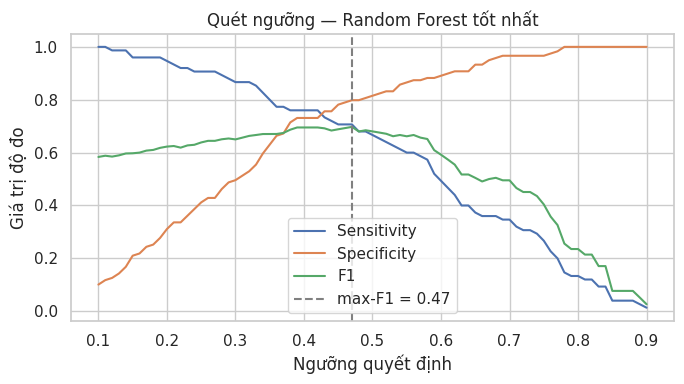

In [12]:
proba_val_best = best_rf.predict_proba(X_val)[:, 1]
ths = np.linspace(0.10, 0.90, 81)
rows = []
for t in ths:
    pred = (proba_val_best >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, pred).ravel()
    rows.append({'threshold': t, 'Sensitivity': tp / (tp + fn),
                 'Specificity': tn / (tn + fp), 'F1': f1_score(y_val, pred),
                 'Accuracy': accuracy_score(y_val, pred)})
th_df = pd.DataFrame(rows)

best_f1_t = float(th_df.loc[th_df['F1'].idxmax(), 'threshold'])
clin = th_df[th_df['Sensitivity'] >= 0.85]
clin_t = float(clin.loc[clin['Specificity'].idxmax(), 'threshold']) if len(clin) else best_f1_t
print('Ngưỡng tối đa F1                         : {:.3f}'.format(best_f1_t))
print('Ngưỡng hướng lâm sàng (Sens≥0.85, Spec↑) : {:.3f}'.format(clin_t))

for t, label in [(best_f1_t, 'tối đa F1'), (clin_t, 'Sens>=0.85')]:
    m = val_metrics_at(best_rf, X_val, y_val, t)
    log_experiment('Best RF + ngưỡng {} ({:.3f})'.format(label, t), best_full_params,
                   gs.best_score_, res.loc[gs.best_index_, 'std_test_score'], m,
                   changed='ngưỡng 0.5 → {:.3f}'.format(t), threshold=t,
                   notes='Cùng mô hình tốt nhất, chỉ thay đổi ngưỡng quyết định.')

plt.figure(figsize=(7, 4))
for c in ['Sensitivity', 'Specificity', 'F1']:
    plt.plot(th_df['threshold'], th_df[c], label=c)
plt.axvline(best_f1_t, ls='--', color='gray', label='max-F1 = {:.2f}'.format(best_f1_t))
plt.xlabel('Ngưỡng quyết định'); plt.ylabel('Giá trị độ đo')
plt.title('Quét ngưỡng — Random Forest tốt nhất'); plt.legend()
plt.tight_layout(); plt.show()

### 7.5 Bảng tổng hợp nhật ký thí nghiệm

Đọc lại `rf_experiment_log.csv` để xem mọi thí nghiệm cạnh nhau (baseline → best → các ngưỡng). Chi tiết người-đọc ở `rf_experiment_log.md`; toàn bộ grid ở `rf_grid_search_all.csv`.

In [13]:
log_table = pd.read_csv(LOG_CSV)
show_cols = ['experiment', 'changed_vs_baseline', 'cv_auc_mean', 'threshold',
             'val_AUC', 'val_Sensitivity', 'val_Specificity', 'val_F1']
print('=== NHẬT KÝ THÍ NGHIỆM (output/rf_experiment_log.csv) ===')
print(log_table[show_cols].to_string(index=False))
print('\nFiles: rf_experiment_log.md (đọc) | rf_experiment_log.csv (bảng) | '
      'rf_grid_search_all.csv ({} tổ hợp)'.format(len(pd.read_csv(GRID_CSV))))

=== NHẬT KÝ THÍ NGHIỆM (output/rf_experiment_log.csv) ===
                          experiment                                changed_vs_baseline  cv_auc_mean  threshold  val_AUC  val_Sensitivity  val_Specificity  val_F1
Baseline (cấu hình hiện tại — mục 4)                                   (mốc tham chiếu)       0.8042       0.50   0.8065           0.6667           0.8067  0.6757
      GridSearch — cấu hình tốt nhất n_estimators: 300 → 500; max_features: sqrt → log2       0.8109       0.50   0.8069           0.6667           0.8151  0.6803
  Best RF + ngưỡng tối đa F1 (0.470)                                 ngưỡng 0.5 → 0.470       0.8109       0.47   0.8069           0.7067           0.7983  0.6974
 Best RF + ngưỡng Sens>=0.85 (0.330)                                 ngưỡng 0.5 → 0.330       0.8109       0.33   0.8069           0.8533           0.5546  0.6667

Files: rf_experiment_log.md (đọc) | rf_experiment_log.csv (bảng) | rf_grid_search_all.csv (1080 tổ hợp)


## 8. Huấn luyện lại trên toàn bộ dữ liệu train (mô hình cuối)

Sau khi đã đánh giá, ta dùng **cấu hình tốt nhất từ mục 7** và huấn luyện lại trên **toàn bộ 970 mẫu** để mô hình cuối tận dụng tối đa dữ liệu trước khi dự đoán tập test (validation chỉ dùng để ước lượng hiệu năng).

In [14]:
rf_final = RandomForestClassifier(
    **best_params, class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE)
rf_final.fit(X, y)
print('Đã huấn luyện mô hình CUỐI (đã tinh chỉnh) trên', X.shape[0], 'mẫu.')
print('Tham số đã chọn:', best_full_params)

Đã huấn luyện mô hình CUỐI (đã tinh chỉnh) trên 970 mẫu.
Tham số đã chọn: {'bootstrap': True, 'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 500, 'class_weight': 'balanced'}


**Nhận xét:** `rf_final` là mô hình sẽ dùng để dự đoán tập test.

## 9. Tiền xử lý `test.json` bằng đúng quy trình của train

Đây là bước **dễ sai** nhất: tập test phải được biến đổi **y hệt** tập train, và **chỉ `transform`** (không `fit`) bằng bộ `preprocessor.joblib` đã lưu — nếu fit lại trên test sẽ gây **rò rỉ dữ liệu**.

Quy trình: `flatten` (min/mean/max) → bỏ cột đã loại → `imputer.transform` → mã hoá phân loại → `scaler.transform` → **căn cột về đúng `feature_cols`** của train (cột one-hot thiếu điền 0).

In [15]:
art = joblib.load(os.path.join(DATA_DIR, 'preprocessor.joblib'))
imputer = art['imputer']
scaler = art['scaler']
numeric_cols = art['numeric_cols']
feature_cols = art['feature_cols']
dropped_cols = art['dropped_cols']
TS_KEYS = art['ts_keys']
STATS = art['stats']

# Các nhóm khác (giống hệt preprocessing.ipynb)
NUM_SCALAR = ['age', 'oasis', 'saps2', 'sofa', 'preiculos', 'egfr']
ALWAYS_BOOL = ['chronic_pulmonary_disease', 'congestive_heart_failure', 'malignant_cancer']
COMORBID_FLAGS = ['hypertension', 'microangiopathy', 'macroangiopathy',
                  'history_ami', 'uti', 'history_aci']
CKD = 'ckd_stage'
ID_COLS = ['subjectId', 'hadmId', 'stayId']

def agg_series(ts):
    a = np.array(list(ts.values()), dtype=float)
    return np.nanmin(a), np.nanmean(a), np.nanmax(a)

def flatten(record):
    m = record['measures']
    row = {'subjectId': record['subjectId'], 'hadmId': record['hadmId'], 'stayId': record['stayId']}
    for k in TS_KEYS:
        v = m.get(k)
        vals = agg_series(v) if isinstance(v, dict) and len(v) > 0 else (np.nan, np.nan, np.nan)
        for s, val in zip(STATS, vals):
            row[f'{k}_{s}'] = val
    for k in NUM_SCALAR + ['gender', 'race', 'liver_disease', 'dka_type']:
        row[k] = m.get(k, np.nan)
    for k in ALWAYS_BOOL + COMORBID_FLAGS:
        row[k] = int(bool(m.get(k, False)))
    row[CKD] = m.get(CKD, 0)
    return row

def group_race(s):
    s = str(s).upper()
    if 'WHITE' in s:
        return 'White'
    if 'BLACK' in s or 'AFRICAN' in s:
        return 'Black'
    if 'HISPANIC' in s or 'LATINO' in s:
        return 'Hispanic'
    if 'ASIAN' in s:
        return 'Asian'
    return 'Other'

def preprocess_records(records):
    """Biến đổi danh sách bản ghi -> (bảng id, ma trận đặc trưng X) khớp với train."""
    df = pd.DataFrame([flatten(r) for r in records])
    ids = df[ID_COLS].copy()
    df = df.drop(columns=dropped_cols, errors='ignore')
    # 1) điền thiếu bằng imputer đã fit trên train (chỉ transform)
    df[numeric_cols] = imputer.transform(df[numeric_cols])
    # 2) mã hoá phân loại y hệt train
    df['gender'] = df['gender'].map({'F': 0, 'M': 1}).fillna(0).astype(int)
    df['liver_disease'] = df['liver_disease'].map({'NONE': 0, 'MILD': 1, 'SEVERE': 2}).fillna(0).astype(int)
    df['race_group'] = df['race'].apply(group_race)
    df = df.drop(columns=['race'])
    df['dka_type'] = df['dka_type'].map({1: 'T1DM', 2: 'T2DM', 0: 'Other'}).fillna('Other')
    df = pd.get_dummies(df, columns=['race_group', 'dka_type'], prefix=['race', 'dka'])
    df[df.select_dtypes(include='bool').columns] = df.select_dtypes(include='bool').astype(int)
    # 3) chuẩn hoá bằng scaler đã fit trên train
    df[numeric_cols] = scaler.transform(df[numeric_cols])
    # 4) căn cột về đúng feature_cols (one-hot thiếu -> 0, đúng thứ tự)
    X_out = df.reindex(columns=feature_cols, fill_value=0)
    return ids, X_out

In [16]:
with open(os.path.join(DATA_DIR, 'test.json'), encoding='utf-8') as f:
    test = json.load(f)

ids_test, X_test = preprocess_records(test)
print('Số bản ghi test:', len(test))
print('Kích thước X_test:', X_test.shape)
print('Khớp đúng cột train?', list(X_test.columns) == list(feature_cols))
print('Còn giá trị thiếu?', bool(X_test.isnull().any().any()))

Số bản ghi test: 243
Kích thước X_test: (243, 77)
Khớp đúng cột train? True
Còn giá trị thiếu? False


**Nhận xét:** `X_test` có **243 × 77**, cột **khớp đúng** thứ tự `feature_cols` của train và **không còn thiếu** — sẵn sàng đưa vào mô hình. (Đã kiểm tra trước: train & test sinh cùng 77 cột, không có nhãn phân loại lạ.)

## 10. Dự đoán tập test & lưu kết quả ra `output/`

File CSV kết quả chỉ gồm **đúng 3 cột**: `id` (= `subjectId`), `probability` (xác suất AKI), `prediction` (nhãn 0/1 ở ngưỡng 0.5).

> **Lưu ý:** một bệnh nhân (`subjectId`) có thể xuất hiện ở **nhiều bản ghi** (khác `hadmId`/`stayId`). Theo yêu cầu, **mỗi `id` chỉ lưu kết quả của một bản ghi** — giữ bản ghi **đầu tiên** xuất hiện trong tập test.

In [17]:
proba_test = rf_final.predict_proba(X_test)[:, 1]
pred_test = (proba_test >= 0.5).astype(int)

# File kết quả chỉ gồm 3 cột: id (= subjectId), probability, prediction
result = pd.DataFrame({
    'id': ids_test['subjectId'].values,
    'probability': np.round(proba_test, 4),
    'prediction': pred_test,
})

# Một bệnh nhân (id = subjectId) có thể có nhiều lần nằm ICU; mỗi id chỉ giữ MỘT bản ghi (đầu tiên).
n_before = len(result)
result = result.drop_duplicates(subset='id', keep='first').reset_index(drop=True)
print('Số bản ghi trước khi gộp: {} | sau khi gộp theo id: {} ({} bản ghi trùng đã loại)'.format(
    n_before, len(result), n_before - len(result)))

out_path = os.path.join(OUTPUT_DIR, 'test_predictions_randomforest.csv')
result.to_csv(out_path, index=False)
print('Đã lưu:', out_path, '| kích thước:', result.shape, '| cột:', list(result.columns))
print('Số ca dự đoán AKI: {} / {} ({:.1%})'.format(
    int(result['prediction'].sum()), len(result), result['prediction'].mean()))

# Lưu lại mô hình cuối để dùng lại nếu cần
joblib.dump(rf_final, os.path.join(OUTPUT_DIR, 'randomforest_model.joblib'))
result.head()

Số bản ghi trước khi gộp: 243 | sau khi gộp theo id: 222 (21 bản ghi trùng đã loại)
Đã lưu: ../output/test_predictions_randomforest.csv | kích thước: (222, 3) | cột: ['id', 'probability', 'prediction']
Số ca dự đoán AKI: 94 / 222 (42.3%)


,id,probability,prediction
0,12789108,0.1127,0
1,11569093,0.4985,0
2,17405009,0.1637,0
3,11721696,0.7015,1
4,19822093,0.5633,1


**Nhận xét:** tập test có 243 bản ghi nhưng chỉ **222 `subjectId` duy nhất**, nên sau khi gộp, file kết quả còn **222 dòng**, mỗi bệnh nhân một dòng với **đúng 3 cột**: `id`, `probability`, `prediction`. Tỉ lệ ca AKI dự đoán nên gần với tỉ lệ ~39% của tập train nếu phân bố test tương tự.